In [1]:
#srun --ntasks=1 --time=01:00:00 --mem=256000 --account=project_2010748 --partition=test --cpus-per-task=1 --x11=first --pty $SHELL
import py_wake as pw
import numpy as np
import xarray as xr
import dask.distributed
import matplotlib.pyplot as plt
import matplotlib.colors as plc
import matplotlib.cm as plcm
import cartopy.crs as ccrs
import cartopy.feature as cft
#mpl.use('Agg')
import pandas as pd
import xesmf as xe
from scipy.spatial import cKDTree
from scipy.optimize import curve_fit
from joblib import Parallel, delayed
import glob
import dask
import os
import socket
from sys import argv

from pyproj import Proj, Transformer, CRS
#from memory_profiler import profile

from py_wake.site import XRSite
from py_wake.site.shear import Shear, PowerShear, MOSTShear
from numpy import newaxis as na
from py_wake.examples.data.dtu10mw import DTU10MW
from py_wake.deficit_models.gaussian import BastankhahGaussianDeficit,IEA37SimpleBastankhahGaussianDeficit
from py_wake.wind_turbines import WindTurbine, WindTurbines
from py_wake.wind_farm_models import PropagateUpDownIterative, PropagateDownwind
from py_wake.superposition_models import LinearSum
from py_wake.deficit_models import VortexDipole
from py_wake.wind_turbines.power_ct_functions import PowerCtTabular
from py_wake.site.distance import StraightDistance
from py_wake.utils.numpy_utils import Numpy32
from py_wake.deflection_models import JimenezWakeDeflection
from py_wake.site._site import get_sector_xr
from py_wake.utils.most import psi

### Calculation for both Power and MOST Shear objects

In [5]:
def Power_func(ws, alpha):
    """
    Function used by PyWake to interpolate the wind speed at h meters using the Power Law Method with exposant alpha.
    """
    h = 10
    h_ref = 100
    alpha = get_sector_xr(alpha, "Power shear coefficient")
    interp_method = 'nearest'
    alpha = alpha.interp_ilk(ws.coords, interp_method=interp_method)
    gain = (h / h_ref) ** alpha
    return (gain[0,:,:] * ws).values.ravel()


def MOST_func(ws, z0, h_zeta, Cm1, Cm2) :
    """
    Function used by PyWake to interpolate the wind speed at h meters using the Monin-Obukhov Similarity Method (MOST).
    """
    h = 10
    h_ref = 100
    z0 = get_sector_xr(z0, "Roughness length")
    interp_method = 'nearest'
    z0 = z0.interp_ilk(ws.coords, interp_method=interp_method)
    L_inv = h_zeta / h_ref  # 1 / Obukhov length
    gain = (np.log(h / z0) - psi(h * L_inv, Cm1=Cm1, Cm2=Cm2)) / (np.log(h_ref / z0) - psi(h_zeta, Cm1=Cm1, Cm2=Cm2))
    return (gain[0,:,:] * ws).values.ravel()


def wake(data,wt_x,wt_y,windTurbines,
         x_reg,y_reg,
         latituderef=59.35,longituderef=20,r=6378e3,region='GoB',dx=1E3,dy=1E3, height=100, k=0.03, m10=False):

    amb10 = np.sqrt(data['10u']**2 + data['10v']**2)
    amb100 = np.sqrt(data['100u']**2 + data['100v']**2)
    
    x_reg2 = xr.DataArray(x_reg,coords={'x':x_reg})
    #print(x_reg2.values)
    #print(x_reg)
    
    y_reg2 = xr.DataArray(y_reg,coords={'y':y_reg})
    
    """WIND DIRECTION"""
    data['wdir'] = np.arctan2(data['100u'], data['100v']) * 180/np.pi + 180 #
    #print(amb100)
    
    # create output data
    if m10 : # is true when we call the function for the 10-meter winds, then the returned dataset should contain the original 10-meter winds
        ds_final = xr.merge([xr.DataArray(amb10.values,dims=('x','y')).to_dataset(name='ws'), #
                             xr.DataArray(data.wdir.values,dims=('x','y')).to_dataset(name='wd'),
                             xr.DataArray(data.mask.values,dims=('x','y')).to_dataset(name='mask'),
                             xr.DataArray(amb10.values.copy(),dims=('x','y')).to_dataset(name='ws_orig'), #
                            ]).assign_coords({'latitude':data.latitude,'longitude':data.longitude,'x':data.x,'y':data.y})
        
        # curve_fit is called to adjust the parameters of the shear object
        para = curve_fit(Power_func, amb100, amb10.values.ravel(), p0=[0.25], maxfev = 4000) #p0=[0.03, 0.0, 5.0, -19.3] # The function used by curve_fit can be changed to either of the two functions above, along with the parameters retrieved and the initial values "p0"
        alphai = para[0][0]
        #z0i = para[0][0]
        #h_zetai = para[0][1]
        #Cm1i = para[0][2]
        #Cm2i = para[0][3]
        
        grid= pw.HorizontalGrid(y=y_reg2.astype(np.float32),x=x_reg2.astype(np.float32), h=10)
        
    else : # If the function is called for the 100-meter winds, the Shear object is not used and the returned dataset contains the original 100-meter winds
        ds_final = xr.merge([xr.DataArray(amb100.values,dims=('x','y')).to_dataset(name='ws'), #
                             xr.DataArray(data.wdir.values,dims=('x','y')).to_dataset(name='wd'),
                             xr.DataArray(data.mask.values,dims=('x','y')).to_dataset(name='mask'),
                             xr.DataArray(amb100.values.copy(),dims=('x','y')).to_dataset(name='ws_orig'), #
                            ]).assign_coords({'latitude':data.latitude,'longitude':data.longitude,'x':data.x,'y':data.y})
        
        z0i = 0.03 # Default parameters of the MOST Shear object
        h_zetai = 0.0
        Cm1i = 5.0
        Cm2i = -19.3
        alphai = 0.25
        
        # create output grid
        grid= pw.HorizontalGrid(y=y_reg2.astype(np.float32),x=x_reg2.astype(np.float32), h=100)
    
    ###################################################################
    #THE DIMENSIONS NEED TO BE X-Y NOT Y-X
    # create input dataset
    
    ds = xr.Dataset(data_vars={'WS':amb100.astype(np.float32), # EITHER WAY, THE WINDS AT 100m ARE FED TO PYWAKE IN THE INPUT DATASET
                             'WD':data.wdir.astype(np.float32),
                             'P':1,
                             'TI':np.float32(0.05)},
    ).assign_coords({'x':data['100u'].x.astype(np.float32), 'y':data['100u'].y.astype(np.float32)}).load()
    #print(ds)
    #print('define wind farm model')

    if m10: #################################################################################################################### Change the Shear object here
        site     = XRSite(ds, distance = StraightDistance(wind_direction = 'WD_i'), bounds = 'ignore', shear = PowerShear(h_ref = 100, alpha = alphai, interp_method = 'nearest') #MOSTShear(h_ref = 100, z0 = z0i, h_zeta = h_zetai, Cm1 = Cm1i, Cm2 = Cm2i, interp_method = 'nearest')
        )
    else:
        site     = XRSite(ds, distance=StraightDistance(wind_direction='WD_i'),bounds='ignore'
        )
    
    wf_model = PropagateDownwind(site, windTurbines,
                                        wake_deficitModel=BastankhahGaussianDeficit(use_effective_ws=True)
                                )
    
    #print('wind farm model starting')
    wf     = wf_model(wt_x.astype(np.float32), wt_y.astype(np.float32),ws=10)
    
    #print('return data on a grid')
    wf_out = wf.flow_map(grid) #.XYGrid(resolution=50000)) #.drop(['wd','ws'])
    #print(wf_out)
    
    
    print('actual calculation is done')
    # Replace with output value where mask
    jinds,iinds = np.where(ds_final.mask)
    ws_final    = ds_final['ws'].values #
    ws_region   = wf_out.WS_eff.drop_vars(['wd','ws']).squeeze()
    #print(wf_out.WS_eff)
    #print(ws_final.shape)
    ws_final[jinds,iinds] = (ws_region.values[iinds,jinds]).flatten()
    ds_final['ws'] = xr.DataArray(ws_final,dims=('x','y')) #
    
    data.close()
    del wf, wf_model
    return ds_final


"""TURBINES"""
print('loop over turbines')
fnamedico = '/users/nathstep/Internship/DMI-HAMOWIOWF/turbines_offshore.csv'
wt_array = pd.read_csv(fnamedico, header=0, index_col=False, usecols=[0, 1], dtype={'longitude':np.float64, 'latitude':np.float64}).to_numpy()
# Select the turbine of the wind farm
###KRIEGERS FLAK###
wt_sel = wt_array[(wt_array[:, 0] < 13.3) & (wt_array[:, 0] > 12.7)]
wt_sel = wt_sel[(wt_sel[:, 1] < 55.15) & (wt_sel[:, 1] > 54.9)]
###EAST ANGLIA###
#wt_sel = wt_array[(wt_array[:, 0] < 2.7) & (wt_array[:, 0] > 2.4)]
#wt_sel = wt_sel[(wt_sel[:, 1] < 52.4) & (wt_sel[:, 1] > 52.1)]
###HORNS REV 3###
#wt_sel = wt_array[(wt_array[:, 0] < 7.9) & (wt_array[:, 0] > 7.4)]
#wt_sel = wt_sel[(wt_sel[:, 1] < 55.8) & (wt_sel[:, 1] > 55.55)]

wt_lon = wt_sel[:, 0]
wt_lat = wt_sel[:, 1]

IEAturbine_carac = pd.read_csv('/users/nathstep/Internship/DMI-HAMOWIOWF/DMI/IEA_Reference_15MW_240.csv',delimiter=',')
power_IEA=IEAturbine_carac['Power [kW]'].values
ct=IEAturbine_carac['Ct [-]'].values
um=IEAturbine_carac['Wind Speed [m/s]'].values
ht=100 # Approximate hub height of Kriegers Flak
D=167 # Rotor diameter of Kriegers Flak
P=15e6

IEA15MW = WindTurbine(name='IEA15MW',
                    diameter=D,
                    hub_height=ht,
                    powerCtFunction=PowerCtTabular(um,power_IEA,'kW',ct))

windTurbines = WindTurbines.from_WindTurbine_lst([IEA15MW])

print('done with the turbines')
print('Number of turbines', len(wt_lon))

region='DMI'

# we need to do smaller subdomains
#Region next to Denmark in PyWake's local system
x_slice = slice(-0.2E6, 0.2E6)
y_slice = slice(-0.1E6, 0.1E6)
print('Slices defined')

# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
fileWF = sorted(glob.glob('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/cropWF*_detail.nc')) # For every file pywake_SHEAR.py placed in the Shear directory
filenoWF = sorted(glob.glob('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/cropnoWF*_detail.nc'))

for i in range(len(fileWF)):
    output_dir = "/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/"
    
    hAVG_noWF = xr.open_dataset(filenoWF[i]).squeeze()
    hAVG_WF = xr.open_dataset(fileWF[i]).squeeze()
    #hAVG_noWF = hAVG_noWF.rename({'lat':'latitude', 'lon':'longitude'})
    
    lon2d = hAVG_noWF['longitude'].values
    lat2d = hAVG_noWF['latitude'].values
    #print(lat2d)
    #hAVG_noWF = hAVG_noWF.assign_coords({'longitude':xr.DataArray(lon2d[:, 0],dims=('longitude')),'latitude':xr.DataArray(lat2d[0, :],dims=('latitude'))})
    #print(hAVG_noWF)
    
    lon_reg = lon2d[:,0] # Centers
    dlon = np.diff(lon_reg)/2
    lon_b = np.concatenate(([lon_reg[0] - dlon[0]], lon_reg[:-1] + dlon, [lon_reg[-1] + dlon[-1]])) # Boundaries
    
    lat_reg = lat2d[0,:] # Centers
    dlat = np.diff(lat_reg)/2
    lat_b = np.concatenate(([lat_reg[0] - dlat[0]], lat_reg[:-1] + dlat, [lat_reg[-1] + dlat[-1]])) # Boundaries
    
    ds_regular_latlon = xr.merge([xr.DataArray(lon_reg,dims=('x')).to_dataset(name='lon'),
                                  xr.DataArray(lat_reg,dims=('y')).to_dataset(name='lat'),
                                  xr.DataArray(lon_b,dims=('x_b')).to_dataset(name='lon_b'),
                                  xr.DataArray(lat_b,dims=('y_b')).to_dataset(name='lat_b')])
    #print(ds_regular_latlon)
    
    # define a regular xy grid reference to the mid-point of the regular lat/lon grid
    latituderef=np.median(lat_reg)
    longituderef=np.median(lon_reg)
    
    # Projectors and Trnasforms
    proj_string = f"+proj=aeqd +lat_0={latituderef} +lon_0={longituderef} +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    proj_local = Proj(proj_string)
    proj_latlon = Proj(proj="latlong", datum="WGS84")
    
    transformer_locTolatlon = Transformer.from_proj(proj_local, proj_latlon)
    transformer_latlonToloc = Transformer.from_proj(proj_latlon, proj_local)
    
    xmin,ymin = transformer_latlonToloc.transform(lon_reg[0],lat_reg[0])
    xmax,ymax = transformer_latlonToloc.transform(lon_reg[-1],lat_reg[-1])
    
    wt_x, wt_y = transformer_latlonToloc.transform(wt_lon, wt_lat) #Turbines
    
    dx=dy=5e2 # Resolution of the local grid: 500m
    x_reg = np.arange(xmin,xmax+dx,dx)
    x_b = np.arange(xmin-dx/2, xmax+dx+dx/2, dx)
    #print(x_reg)
    
    y_reg = np.arange(ymin,ymax+dy,dy)
    y_b = np.arange(ymin-dy/2, ymax+dy+dy/2, dy)
    #print(y_reg)
    
    y2d,x2d = np.meshgrid(y_reg,x_reg)
    y_b2d,x_b2d = np.meshgrid(y_b, x_b) 
    lon2dxy,lat2dxy = transformer_locTolatlon.transform(x2d,y2d)
    lon_b2dxy, lat_b2dxy = transformer_locTolatlon.transform(x_b2d,y_b2d)
    #print(x2d)
    #print(x2d.shape)
    
    # create datasets for both
    ds_regular=xr.merge([xr.DataArray(lat2d,dims=('x','y')).to_dataset(name='latitude'),
                        xr.DataArray(lon2d,dims=('x','y')).to_dataset(name='longitude')]
    )
    ds_regular_xy=xr.merge([xr.DataArray(lat2dxy,dims=('x','y')).to_dataset(name='latitude'),
                            xr.DataArray(lon2dxy,dims=('x','y')).to_dataset(name='longitude'),
                            xr.DataArray(lat_b2dxy,dims=('x_b','y_b')).to_dataset(name='lat_b'),
                            xr.DataArray(lon_b2dxy,dims=('x_b','y_b')).to_dataset(name='lon_b')]
                        )
    #print(ds_regular_xy)
    #print(hAVG_noWF['100u'])
    
    # regrid hAVG to the regular xy grid
    regridder_hAVG_noWF = xe.Regridder(hAVG_noWF, ds_regular_xy, "bilinear",filename='/users/nathstep/Internship/DMI-HAMOWIOWF/DMI/hAVG_to_regular_precise.nc', reuse_weights=True) # You may turn this to False to reinitialize the weights if an error occur, then to True again
    regridder_xy2latlon = xe.Regridder(ds_regular_xy,ds_regular_latlon, "conservative",filename='/users/nathstep/Internship/DMI-HAMOWIOWF/DMI/hAVG_XY_to_regular_conserv.nc', reuse_weights=True) # You may turn this to False to reinitialize the weights if an error occur, then to True again
    
    data=regridder_hAVG_noWF(hAVG_noWF)
    
    #print(data['100u'])
    
    data=data.assign_coords({'longitude':ds_regular_xy.longitude,'latitude':ds_regular_xy.latitude,
                            'x':xr.DataArray(x_reg,dims=('x')),'y':xr.DataArray(y_reg,dims=('y'))})

    data=xr.merge([data,xr.DataArray(xr.zeros_like(data['100u'])).to_dataset(name='mask')]) # Initializing the mask
    mask = np.logical_and(np.logical_and(x2d>x_slice.start,x2d<x_slice.stop),np.logical_and(y2d>y_slice.start,y2d<y_slice.stop))
    data.mask.values = mask[:,:]
    #print('Applied mask')
    
    ds_final = wake(data, wt_x, wt_y, windTurbines, # Calculation for the 100-meter winds, just so the dataset is complete and contains both heights
        x_reg, y_reg, region=region, dy=dy, dx=dx, height=100, m10=False)
    ds_final = ds_final.drop_vars(['mask'])
    
    ds10 = wake(data, wt_x, wt_y, windTurbines, # Calculation for the 10-meter winds
        x_reg, y_reg, region=region, dy=dy, dx=dx, height=10, m10=True)
    
    ds_final['10ws'] = ds10['ws']
    
    # REGRIDDING MUST BE DONE WITH U AND V
    v = -ds_final['ws'] * np.cos(ds_final['wd']*np.pi/180) #
    u = -ds_final['ws'] * np.sin(ds_final['wd']*np.pi/180) #
    
    v10 = -ds_final['10ws'] * np.cos(ds_final['wd']*np.pi/180) #
    u10 = -ds_final['10ws'] * np.sin(ds_final['wd']*np.pi/180) #
    
    ds_final['100u'] = (('x','y'), u.data) #
    ds_final['100v'] = (('x','y'), v.data) #
    
    ds_final['10u'] = (('x','y'), u10.data) #
    ds_final['10v'] = (('x','y'), v10.data) #
    
    ds_final_reg = regridder_xy2latlon(ds_final).assign_coords({'longitude':ds_regular.longitude, 'latitude':ds_regular.latitude}).transpose('x', 'y')
    
    """WIND DIRECTION"""
    ds_final_reg['wd'] = np.arctan2(ds_final_reg['100u'], ds_final_reg['100v']) * 180/np.pi + 180 #
    
    """WIND SPEED"""
    ds_final_reg['ws'] = np.sqrt(ds_final_reg['100u']**2 + ds_final_reg['100v']**2) #
    ds_final_reg['10ws'] = np.sqrt(ds_final_reg['10u']**2 + ds_final_reg['10v']**2) #
    #print(ds_final_reg)
    
    file = output_dir + region + '_reg_POWER_' + fileWF[i][61:72] + '.nc' # Name of the file
    
    ds_final_reg.to_netcdf(file, engine='netcdf4')
    print(f'regridding and netcdf done to : {file}')
print("Done with everything")

loop over turbines
done with the turbines
Number of turbines 152
Slices defined
actual calculation is done
actual calculation is done
regridding and netcdf done to : /scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/DMI_reg_POWER_2025120221_.nc
actual calculation is done
actual calculation is done
regridding and netcdf done to : /scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/DMI_reg_POWER_2025120300_.nc
actual calculation is done
actual calculation is done
regridding and netcdf done to : /scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/DMI_reg_POWER_2025120303_.nc
actual calculation is done
actual calculation is done
regridding and netcdf done to : /scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/DMI_reg_POWER_2025120306_.nc
actual calculation is done
actual calculation is done
regridding and netcdf done to : /scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/DMI_reg_POWER_2025120309_.nc
actual calculation is done
actual calculation is done
regridding and n

### Averaging code  
To avoid opening 800+ timestamp at the same time, they are divided in 20 packages.

In [23]:
filenoWF = sorted(glob.glob('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/mid/cropnoWF*_detail.nc'))
filepy = sorted(glob.glob('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/mid/DMI_area_KriegersFlak_*.nc'))
disect = 20
par = len(filenoWF)//disect
for i in range(disect):
    if i == disect-1 :
        pAVG = xr.open_mfdataset(filepy[i*par:], combine='nested', concat_dim='time', parallel=False, chunks={'time':3}, coords='minimal')
        hAVG_noWF = xr.open_mfdataset(filenoWF[i*par:], combine='nested', concat_dim='time', parallel=False, chunks={'time':3}, coords='minimal')
    else :
        pAVG = xr.open_mfdataset(filepy[i*par:(i+1)*par], combine='nested', concat_dim='time', parallel=False, chunks={'time':3}, coords='minimal')
        hAVG_noWF = xr.open_mfdataset(filenoWF[i*par:(i+1)*par], combine='nested', concat_dim='time', parallel=False, chunks={'time':3}, coords='minimal')

    pAVG['ws'] = pAVG['ws']/np.sqrt(hAVG_noWF['100v']**2 + hAVG_noWF['100u']**2) - 1. # Velocity deficit (negative) normalized on the speed without wind farms
    pAVG['10ws'] = pAVG['10ws']/np.sqrt(hAVG_noWF['10v']**2 + hAVG_noWF['10u']**2) - 1.
    pAVG = pAVG.drop_vars(['10u','10v','100u','100v'])

    pAVG = pAVG.mean(dim='time')

    pAVG.to_netcdf('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/mid/pyAVG_area_package' + str(i).zfill(2) + '.nc', engine='netcdf4')
    print(f"Done with package {i}")

Done with package 0
Done with package 1
Done with package 2
Done with package 3
Done with package 4
Done with package 5
Done with package 6
Done with package 7
Done with package 8
Done with package 9
Done with package 10
Done with package 11
Done with package 12
Done with package 13
Done with package 14
Done with package 15
Done with package 16
Done with package 17
Done with package 18
Done with package 19


In [24]:
filepy = sorted(glob.glob('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/mid/pyAVG_area_package*.nc'))
pAVG = xr.open_mfdataset(filepy, combine='nested', concat_dim='time', parallel=False, chunks={'time':3}, coords='minimal')
pAVG = pAVG.mean(dim='time')
pAVG.to_netcdf('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/mid/pyAVG_area.nc', engine='netcdf4')
print("Done")

Done


-----------------------------------------------

In [24]:
filenoWF = sorted(glob.glob('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/cropnoWF*_detail.nc'))
fileWF = sorted(glob.glob('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/cropWF*_detail.nc'))

disect = 20
par = len(filenoWF)//disect
for i in range(disect):
    if i == disect-1 :
        hAVG_WF = xr.open_mfdataset(fileWF[i*par:], combine='nested', concat_dim='time', parallel=False, chunks={'time':3}, coords='minimal')
        hAVG_noWF = xr.open_mfdataset(filenoWF[i*par:], combine='nested', concat_dim='time', parallel=False, chunks={'time':3}, coords='minimal')
    else :
        hAVG_WF = xr.open_mfdataset(fileWF[i*par:(i+1)*par], combine='nested', concat_dim='time', parallel=False, chunks={'time':3}, coords='minimal')
        hAVG_noWF = xr.open_mfdataset(filenoWF[i*par:(i+1)*par], combine='nested', concat_dim='time', parallel=False, chunks={'time':3}, coords='minimal')

    hAVG_WF['ws'] = np.sqrt(hAVG_WF['100v']**2 + hAVG_WF['100u']**2)
    hAVG_WF['10ws'] = np.sqrt(hAVG_WF['10v']**2 + hAVG_WF['10u']**2)
    hAVG_noWF['ws'] = np.sqrt(hAVG_noWF['100v']**2 + hAVG_noWF['100u']**2)
    hAVG_noWF['10ws'] = np.sqrt(hAVG_noWF['10v']**2 + hAVG_noWF['10u']**2)
    
    hAVG_WF['ws'] = hAVG_WF['ws']/hAVG_noWF['ws'] - 1.
    hAVG_WF['10ws'] = hAVG_WF['10ws']/hAVG_noWF['10ws'] - 1.
    hAVG = hAVG_WF.drop_vars(['10u','10v','100u','100v'])

    hAVG = hAVG.mean(dim='time')

    hAVG.to_netcdf('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/hAVG_package' + str(i).zfill(2) + '.nc', engine='netcdf4')
    print(f"Done with package {i}")

Done with package 0
Done with package 1
Done with package 2
Done with package 3
Done with package 4
Done with package 5
Done with package 6
Done with package 7
Done with package 8
Done with package 9
Done with package 10
Done with package 11
Done with package 12
Done with package 13
Done with package 14
Done with package 15
Done with package 16
Done with package 17
Done with package 18
Done with package 19


In [25]:
file = sorted(glob.glob('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/hAVG_package*.nc'))
hAVG = xr.open_mfdataset(file, combine='nested', concat_dim='time', parallel=False, chunks={'time':3}, coords='minimal')
hAVG = hAVG.mean(dim='time')
hAVG.to_netcdf('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/hAVG.nc', engine='netcdf4')
print("Done")

Done


### Plotting data  
#### Comparison with the first correlation (10-meter winds)

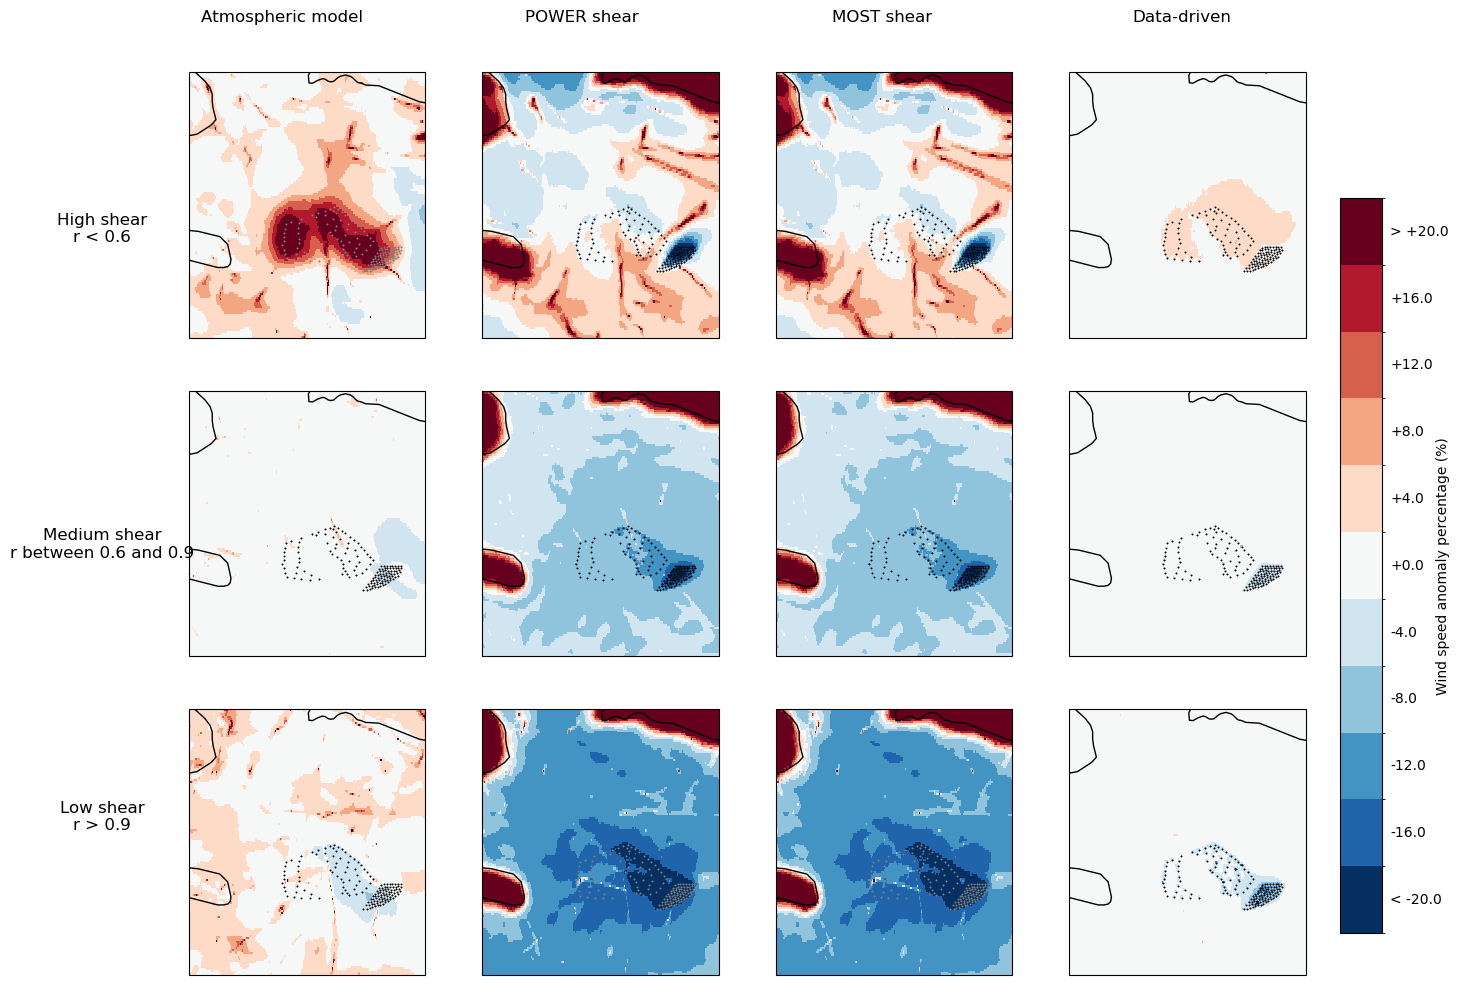

In [26]:
data_folder = '/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/'
work_dir = '/users/nathstep/Internship/DMI-HAMOWIOWF/'

"""TURBINES"""
fnamedico = work_dir + 'turbines_offshore.csv'
wt = pd.read_csv(fnamedico, header=0, index_col=False, usecols=[0, 1], dtype={'longitude':np.float64, 'latitude':np.float64}).to_numpy()

cmap = plcm.RdBu_r
step = 0.04
bounds = np.arange(-0.2 - step/2, 0.2 + step/2 + step, step)
norm = plc.BoundaryNorm(bounds, cmap.N)

h = xr.open_dataset(data_folder + 'low/hAVG.nc')
pyPOWER = xr.open_dataset(data_folder + 'low/pyAVG_POWER.nc')
pyMOST = xr.open_dataset(data_folder + 'low/pyAVG_MOST.nc')
pyCO = xr.open_dataset(data_folder + 'low/pyAVG_cor.nc')

proj1=ccrs.NearsidePerspective(central_longitude=15.5,central_latitude=52,satellite_height=1400E3)
fig,ax=plt.subplots(nrows=3,ncols=4,sharex=True,sharey=True,figsize=(15,10.5),subplot_kw={'projection':proj1})
mesh1 = ax[0,0].pcolormesh(h.longitude, h.latitude, h['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[0,0].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='gray', markersize=0.8, transform=ccrs.PlateCarree())
ax[0,0].coastlines(resolution='10m')
ax[0,0].set_extent([12.4,13.5,54.6,55.5])
ax[0,0].set_xlabel('Longitude (°)')
ax[0,0].set_ylabel('Latitude (°)')

mesh2 = ax[0,1].pcolormesh(pyPOWER.longitude, pyPOWER.latitude, pyPOWER['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[0,1].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.8, transform=ccrs.PlateCarree())
ax[0,1].coastlines(resolution='10m')
ax[0,1].set_extent([12.4,13.5,54.6,55.5])
ax[0,1].set_xlabel('Longitude (°)')
ax[0,1].set_ylabel('Latitude (°)')

mesh3 = ax[0,2].pcolormesh(pyMOST.longitude, pyMOST.latitude, pyMOST['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[0,2].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.8, transform=ccrs.PlateCarree())
ax[0,2].coastlines(resolution='10m')
ax[0,2].set_extent([12.4,13.5,54.6,55.5])
ax[0,2].set_xlabel('Longitude (°)')
ax[0,2].set_ylabel('Latitude (°)')

mesh4 = ax[0,3].pcolormesh(pyCO.longitude, pyCO.latitude, pyCO['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[0,3].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.8, transform=ccrs.PlateCarree())
ax[0,3].coastlines(resolution='10m')
ax[0,3].set_extent([12.4,13.5,54.6,55.5])
ax[0,3].set_xlabel('Longitude (°)')
ax[0,3].set_ylabel('Latitude (°)')

##############################################################################################

h = xr.open_dataset(data_folder + 'mid/hAVG.nc')
pyPOWER = xr.open_dataset(data_folder + 'mid/pyAVG_POWER.nc')
pyMOST = xr.open_dataset(data_folder + 'mid/pyAVG_MOST.nc')
pyCO = xr.open_dataset(data_folder + 'mid/pyAVG_cor.nc')

mesh5 = ax[1,0].pcolormesh(h.longitude, h.latitude, h['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[1,0].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.8, transform=ccrs.PlateCarree())
ax[1,0].coastlines(resolution='10m')
ax[1,0].set_extent([12.4,13.5,54.6,55.5])
ax[1,0].set_xlabel('Longitude (°)')
ax[1,0].set_ylabel('Latitude (°)')

mesh6 = ax[1,1].pcolormesh(pyPOWER.longitude, pyPOWER.latitude, pyPOWER['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[1,1].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.8, transform=ccrs.PlateCarree())
ax[1,1].coastlines(resolution='10m')
ax[1,1].set_extent([12.4,13.5,54.6,55.5])
ax[1,1].set_xlabel('Longitude (°)')
ax[1,1].set_ylabel('Latitude (°)')

mesh7= ax[1,2].pcolormesh(pyMOST.longitude, pyMOST.latitude, pyMOST['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[1,2].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.8, transform=ccrs.PlateCarree())
ax[1,2].coastlines(resolution='10m')
ax[1,2].set_extent([12.4,13.5,54.6,55.5])
ax[1,2].set_xlabel('Longitude (°)')
ax[1,2].set_ylabel('Latitude (°)')

mesh8 = ax[1,3].pcolormesh(pyCO.longitude, pyCO.latitude, pyCO['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[1,3].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.8, transform=ccrs.PlateCarree())
ax[1,3].coastlines(resolution='10m')
ax[1,3].set_extent([12.4,13.5,54.6,55.5])
ax[1,3].set_xlabel('Longitude (°)')
ax[1,3].set_ylabel('Latitude (°)')

##############################################################################################

h = xr.open_dataset(data_folder + 'high/hAVG.nc')
pyPOWER = xr.open_dataset(data_folder + 'high/pyAVG_POWER.nc')
pyMOST = xr.open_dataset(data_folder + 'high/pyAVG_MOST.nc')
pyCO = xr.open_dataset(data_folder + 'high/pyAVG_cor.nc')

ax[2,0].pcolormesh(h.longitude, h.latitude, h['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[2,0].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.8, transform=ccrs.PlateCarree())
ax[2,0].coastlines(resolution='10m')
ax[2,0].set_extent([12.4,13.5,54.6,55.5])
ax[2,0].set_xlabel('Longitude (°)')
ax[2,0].set_ylabel('Latitude (°)')

ax[2,1].pcolormesh(pyPOWER.longitude, pyPOWER.latitude, pyPOWER['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[2,1].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='gray', markersize=0.8, transform=ccrs.PlateCarree())
ax[2,1].coastlines(resolution='10m')
ax[2,1].set_extent([12.4,13.5,54.6,55.5])
ax[2,1].set_xlabel('Longitude (°)')
ax[2,1].set_ylabel('Latitude (°)')

ax[2,2].pcolormesh(pyMOST.longitude, pyMOST.latitude, pyMOST['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[2,2].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='gray', markersize=0.8, transform=ccrs.PlateCarree())
ax[2,2].coastlines(resolution='10m')
ax[2,2].set_extent([12.4,13.5,54.6,55.5])
ax[2,2].set_xlabel('Longitude (°)')
ax[2,2].set_ylabel('Latitude (°)')

ax[2,3].pcolormesh(pyCO.longitude, pyCO.latitude, pyCO['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[2,3].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.8, transform=ccrs.PlateCarree())
ax[2,3].coastlines(resolution='10m')
ax[2,3].set_extent([12.4,13.3,54.8,55.4])
ax[2,3].set_xlabel('Longitude (°)')
ax[2,3].set_ylabel('Latitude (°)')

fig.subplots_adjust(left=0.06)
title_ax1 = fig.add_axes([0.0, 0.14, 0.01, 0.1])
title_ax1.set_axis_off()
title_ax1.set_title("Low shear\nr > 0.9")
title_ax2 = fig.add_axes([0.0, 0.4, 0.01, 0.1])
title_ax2.set_axis_off()
title_ax2.set_title("Medium shear\nr between 0.6 and 0.9")
title_ax3 = fig.add_axes([0.0, 0.7, 0.01, 0.1])
title_ax3.set_axis_off()
title_ax3.set_title("High shear\nr < 0.6")

fig.subplots_adjust(top=0.97)
title_ax4 = fig.add_axes([0.0, 1.0, 0.25, 0.01])
title_ax4.set_axis_off()
title_ax4.set_title("Atmospheric model")
title_ax5 = fig.add_axes([0.2, 1.0, 0.25, 0.01])
title_ax5.set_axis_off()
title_ax5.set_title("POWER shear")
title_ax6 = fig.add_axes([0.4, 1.0, 0.25, 0.01])
title_ax6.set_axis_off()
title_ax6.set_title("MOST shear")
title_ax7 = fig.add_axes([0.6, 1.0, 0.25, 0.01])
title_ax7.set_axis_off()
title_ax7.set_title("Data-driven")

fig.subplots_adjust(right=0.81)
cbar_ax = fig.add_axes([0.83, 0.15, 0.028, 0.7])
cbar = fig.colorbar(mesh1, cax=cbar_ax)
cbar_ax.get_yaxis().set_ticks([])
for j, lab in enumerate(np.round((bounds[:-1] + step/2) * 100, decimals=1).astype(str)):
    if j == len(bounds[:-1])-1 :
        cbar_ax.text(1.2, j / len(bounds[:-1]) + 1/(2 * len(bounds[:-1])), '> +' + lab, ha='left', va='center', transform=cbar_ax.transAxes)
    elif j == 0 :
        cbar_ax.text(1.2, j / len(bounds[:-1]) + 1/(2 * len(bounds[:-1])), '< ' + lab, ha='left', va='center', transform=cbar_ax.transAxes)
    elif float(lab) >= 0 :
        cbar_ax.text(1.2, j / len(bounds[:-1]) + 1/(2 * len(bounds[:-1])), '+' + lab, ha='left', va='center', transform=cbar_ax.transAxes)
    else :
        cbar_ax.text(1.2, j / len(bounds[:-1]) + 1/(2 * len(bounds[:-1])), lab, ha='left', va='center', transform=cbar_ax.transAxes)
cbar.set_label('Wind speed anomaly percentage (%)', labelpad = 34)
#plt.savefig('/users/nathstep/Internship/DMI-HAMOWIOWF/shear_comparison.png')

#### Comparison with the second correlation (rotor diameter)

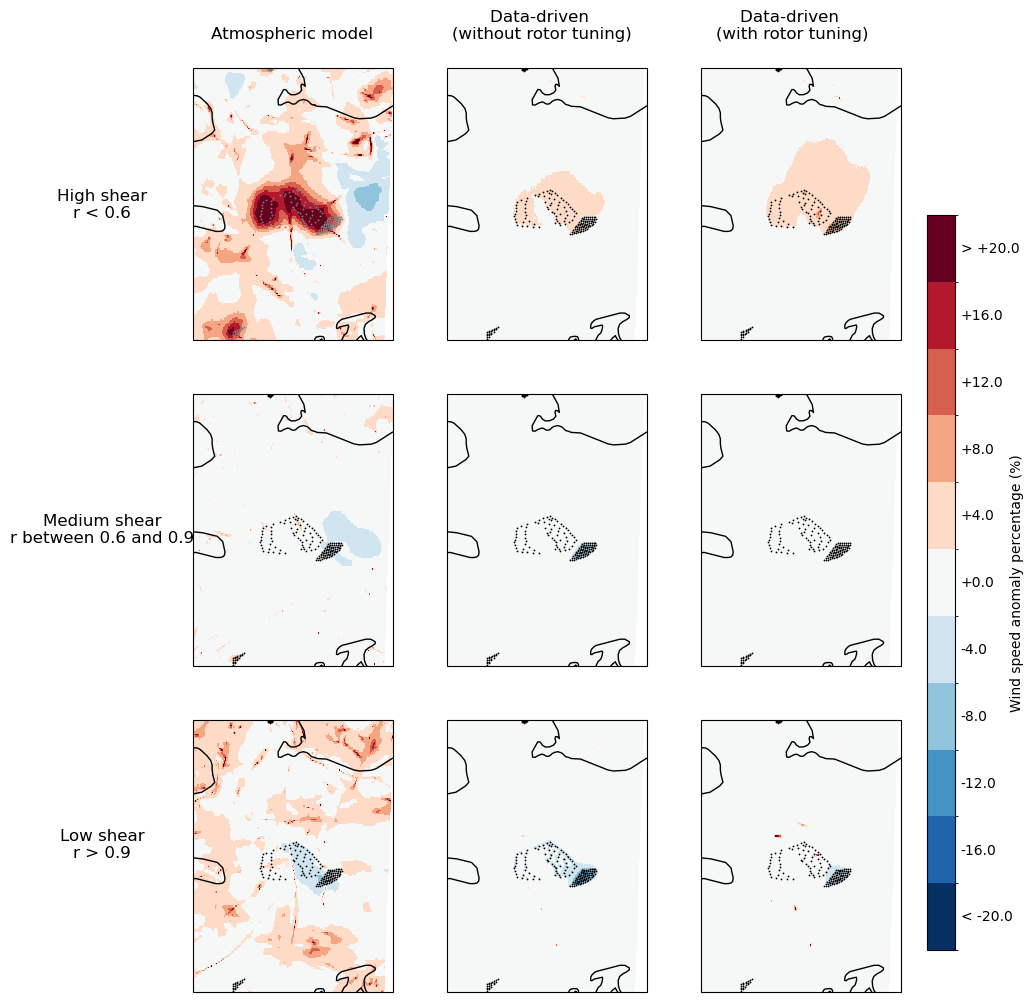

In [27]:
"""TURBINES"""
fnamedico = '/users/nathstep/Internship/DMI-HAMOWIOWF/turbines_offshore.csv'
wt = pd.read_csv(fnamedico, header=0, index_col=False, usecols=[0, 1], dtype={'longitude':np.float64, 'latitude':np.float64}).to_numpy()

cmap = plcm.RdBu_r
step = 0.04
bounds = np.arange(-0.2 - step/2, 0.2 + step/2 + step, step)
norm = plc.BoundaryNorm(bounds, cmap.N)

h = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/low/hAVG.nc')
pyCO = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/low/pyAVG_cor.nc')
pyAREA = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/low/pyAVG_area.nc')

proj1=ccrs.NearsidePerspective(central_longitude=15.5,central_latitude=52,satellite_height=1400E3)
fig,ax=plt.subplots(nrows=3,ncols=3,sharex=True,sharey=True,figsize=(10,10.5),subplot_kw={'projection':proj1})
mesh1 = ax[0,0].pcolormesh(h.longitude, h.latitude, h['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[0,0].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='gray', markersize=0.7, transform=ccrs.PlateCarree())
ax[0,0].coastlines(resolution='10m')
ax[0,0].set_extent([12.4,13.5,54.6,55.5])
ax[0,0].set_xlabel('Longitude (°)')
ax[0,0].set_ylabel('Latitude (°)')

mesh2 = ax[0,1].pcolormesh(pyCO.longitude.values[4:-4,2:-2], pyCO.latitude.values[4:-4,2:-2], pyCO['10ws'].values[4:-4,2:-2], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[0,1].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.7, transform=ccrs.PlateCarree())
ax[0,1].coastlines(resolution='10m')
ax[0,1].set_extent([12.4,13.5,54.6,55.5])
ax[0,1].set_xlabel('Longitude (°)')
ax[0,1].set_ylabel('Latitude (°)')

mesh3 = ax[0,2].pcolormesh(pyAREA.longitude.values[4:-4,2:-2], pyAREA.latitude.values[4:-4,2:-2], pyAREA['10ws'].values[4:-4,2:-2], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[0,2].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.7, transform=ccrs.PlateCarree())
ax[0,2].coastlines(resolution='10m')
ax[0,2].set_extent([12.4,13.5,54.6,55.5])
ax[0,2].set_xlabel('Longitude (°)')
ax[0,2].set_ylabel('Latitude (°)')

##############################################################################################

h = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/mid/hAVG.nc')
pyCO = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/mid/pyAVG_cor.nc')
pyAREA = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/mid/pyAVG_area.nc')

mesh5 = ax[1,0].pcolormesh(h.longitude, h.latitude, h['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[1,0].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.7, transform=ccrs.PlateCarree())
ax[1,0].coastlines(resolution='10m')
ax[1,0].set_extent([12.4,13.5,54.6,55.5])
ax[1,0].set_xlabel('Longitude (°)')
ax[1,0].set_ylabel('Latitude (°)')

mesh6 = ax[1,1].pcolormesh(pyCO.longitude.values[4:-4,2:-2], pyCO.latitude.values[4:-4,2:-2], pyCO['10ws'].values[4:-4,2:-2], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[1,1].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.7, transform=ccrs.PlateCarree())
ax[1,1].coastlines(resolution='10m')
ax[1,1].set_extent([12.4,13.5,54.6,55.5])
ax[1,1].set_xlabel('Longitude (°)')
ax[1,1].set_ylabel('Latitude (°)')

mesh7= ax[1,2].pcolormesh(pyAREA.longitude.values[4:-4,2:-2], pyAREA.latitude.values[4:-4,2:-2], pyAREA['10ws'].values[4:-4,2:-2], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[1,2].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.7, transform=ccrs.PlateCarree())
ax[1,2].coastlines(resolution='10m')
ax[1,2].set_extent([12.4,13.5,54.6,55.5])
ax[1,2].set_xlabel('Longitude (°)')
ax[1,2].set_ylabel('Latitude (°)')

##############################################################################################

h = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/hAVG.nc')
pyCO = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/pyAVG_cor.nc')
pyAREA = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/high/pyAVG_area.nc')

ax[2,0].pcolormesh(h.longitude, h.latitude, h['10ws'], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[2,0].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.7, transform=ccrs.PlateCarree())
ax[2,0].coastlines(resolution='10m')
ax[2,0].set_extent([12.4,13.5,54.6,55.5])
ax[2,0].set_xlabel('Longitude (°)')
ax[2,0].set_ylabel('Latitude (°)')

ax[2,1].pcolormesh(pyCO.longitude.values[4:-4,2:-2], pyCO.latitude.values[4:-4,2:-2], pyCO['10ws'].values[4:-4,2:-2], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[2,1].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.7, transform=ccrs.PlateCarree())
ax[2,1].coastlines(resolution='10m')
ax[2,1].set_extent([12.4,13.5,54.6,55.5])
ax[2,1].set_xlabel('Longitude (°)')
ax[2,1].set_ylabel('Latitude (°)')

ax[2,2].pcolormesh(pyAREA.longitude.values[4:-4,2:-2], pyAREA.latitude.values[4:-4,2:-2], pyAREA['10ws'].values[4:-4,2:-2], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
ax[2,2].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='black', markersize=0.7, transform=ccrs.PlateCarree())
ax[2,2].coastlines(resolution='10m')
ax[2,2].set_extent([12.4,13.5,54.6,55.5])
ax[2,2].set_xlabel('Longitude (°)')
ax[2,2].set_ylabel('Latitude (°)')

fig.subplots_adjust(left=0.09)
title_ax1 = fig.add_axes([0.0, 0.13, 0.01, 0.1])
title_ax1.set_axis_off()
title_ax1.set_title("Low shear\nr > 0.9")
title_ax2 = fig.add_axes([0.0, 0.43, 0.01, 0.1])
title_ax2.set_axis_off()
title_ax2.set_title("Medium shear\nr between 0.6 and 0.9")
title_ax3 = fig.add_axes([0.0, 0.74, 0.01, 0.1])
title_ax3.set_axis_off()
title_ax3.set_title("High shear\nr < 0.6")

fig.subplots_adjust(top=0.99)
title_ax4 = fig.add_axes([0.03, 1.0, 0.33, 0.01])
title_ax4.set_axis_off()
title_ax4.set_title("Atmospheric model")
title_ax5 = fig.add_axes([0.28, 1.0, 0.33, 0.01])
title_ax5.set_axis_off()
title_ax5.set_title("Data-driven \n(without rotor tuning)")
title_ax6 = fig.add_axes([0.53, 1.0, 0.33, 0.01])
title_ax6.set_axis_off()
title_ax6.set_title("Data-driven \n(with rotor tuning)")

fig.subplots_adjust(right=0.81)
cbar_ax = fig.add_axes([0.83, 0.15, 0.028, 0.7])
cbar = fig.colorbar(mesh1, cax=cbar_ax)
cbar_ax.get_yaxis().set_ticks([])
for j, lab in enumerate(np.round((bounds[:-1] + step/2) * 100, decimals=1).astype(str)):
    if j == len(bounds[:-1])-1 :
        cbar_ax.text(1.2, j / len(bounds[:-1]) + 1/(2 * len(bounds[:-1])), '> +' + lab, ha='left', va='center', transform=cbar_ax.transAxes)
    elif j == 0 :
        cbar_ax.text(1.2, j / len(bounds[:-1]) + 1/(2 * len(bounds[:-1])), '< ' + lab, ha='left', va='center', transform=cbar_ax.transAxes)
    elif float(lab) >= 0 :
        cbar_ax.text(1.2, j / len(bounds[:-1]) + 1/(2 * len(bounds[:-1])), '+' + lab, ha='left', va='center', transform=cbar_ax.transAxes)
    else :
        cbar_ax.text(1.2, j / len(bounds[:-1]) + 1/(2 * len(bounds[:-1])), lab, ha='left', va='center', transform=cbar_ax.transAxes)
cbar.set_label('Wind speed anomaly percentage (%)', labelpad = 34)
#plt.savefig('/users/nathstep/Internship/DMI-HAMOWIOWF/shear_comparison.png')

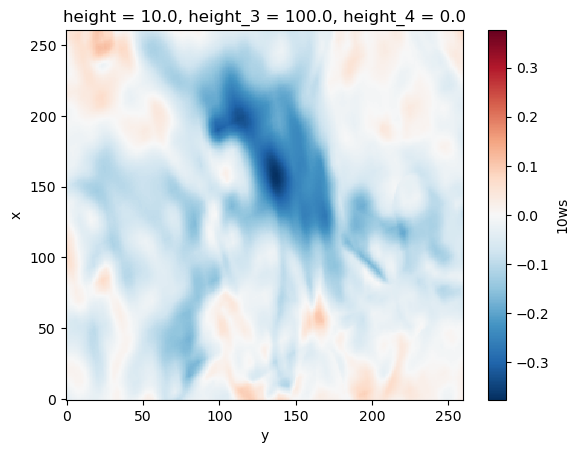

In [25]:
h_noWF = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/mid/hAVG_noWF.nc')
h_WF = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/Shear/mid/hAVG_WF.nc')
(h_WF['10ws']-h_noWF['10ws']).plot()